In [2]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import mlflow
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
project_root = os.path.abspath("..")  
sys.path.append(project_root)
from sklearn.metrics import classification_report, confusion_matrix
from src.data_loader import GripSequenceDataset
from src.model import GripTransformerClassifier

In [3]:
# Config 
RUN_ID = "1ef87fb427844a599fff17a00e00972d"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load origin config file to get model params
with open("C:/CourseWork/Classifying_grip_strategies_ml/config/params.yaml", "r") as f:
    config = yaml.safe_load(f)

print(f"Using device: {DEVICE}")
print(f"Loading model from MLflow Run ID: {RUN_ID}")

Using device: cuda
Loading model from MLflow Run ID: 1ef87fb427844a599fff17a00e00972d


In [4]:
mlflow.set_tracking_uri("file:///C:/CourseWork/Classifying_grip_strategies_ml/mlruns")

model_uri = f"runs:/{RUN_ID}/best_model"
model = mlflow.pytorch.load_model(model_uri, map_location=DEVICE)
model.eval()
print("Model loaded successfully!")


Model loaded successfully!


In [5]:
# Load the test data
processed_path = config["data"]["processed_path"]
test_dataset = GripSequenceDataset(f"{processed_path}/X_test.npy", f"{processed_path}/y_test.npy")
test_loader = DataLoader(test_dataset, batch_size=config["training"]["batch_size"], shuffle=False)

raw_df = pd.read_csv("C:/CourseWork/Classifying_grip_strategies_ml/data/02_processed/GripFormer_preprocessed_dataset.csv")
raw_df.columns = [col.strip() for col in raw_df.columns]
label_map = raw_df[["label_encoded", "label"]].drop_duplicates().sort_values("label_encoded").set_index("label_encoded")
label_names = label_map["label"].tolist()
print("Test Data Loaded")

Test Data Loaded


In [6]:
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(DEVICE), labels.to(DEVICE)

        outputs = model(features, return_attention=False)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Gen and print classification report
print("--- Classification Report (Test Set) ---")
print(classification_report(all_labels, all_preds, target_names=label_names, zero_division=0))

--- Classification Report (Test Set) ---
                                              precision    recall  f1-score   support

                       aiming_bino_black_one       0.17      0.17      0.17         6
                     aiming_bino_black_three       0.22      0.33      0.27        12
                       aiming_bino_black_two       0.00      0.00      0.00         9
                        aiming_bino_wood_one       0.17      0.20      0.18        10
                      aiming_bino_wood_three       0.00      0.00      0.00        11
                        aiming_bino_wood_two       0.00      0.00      0.00         8
                      aiming_clear_black_one       0.12      0.17      0.14         6
                    aiming_clear_black_three       0.23      0.33      0.27         9
                      aiming_clear_black_two       1.00      0.12      0.22         8
                       aiming_clear_wood_one       0.24      0.31      0.27        13
            

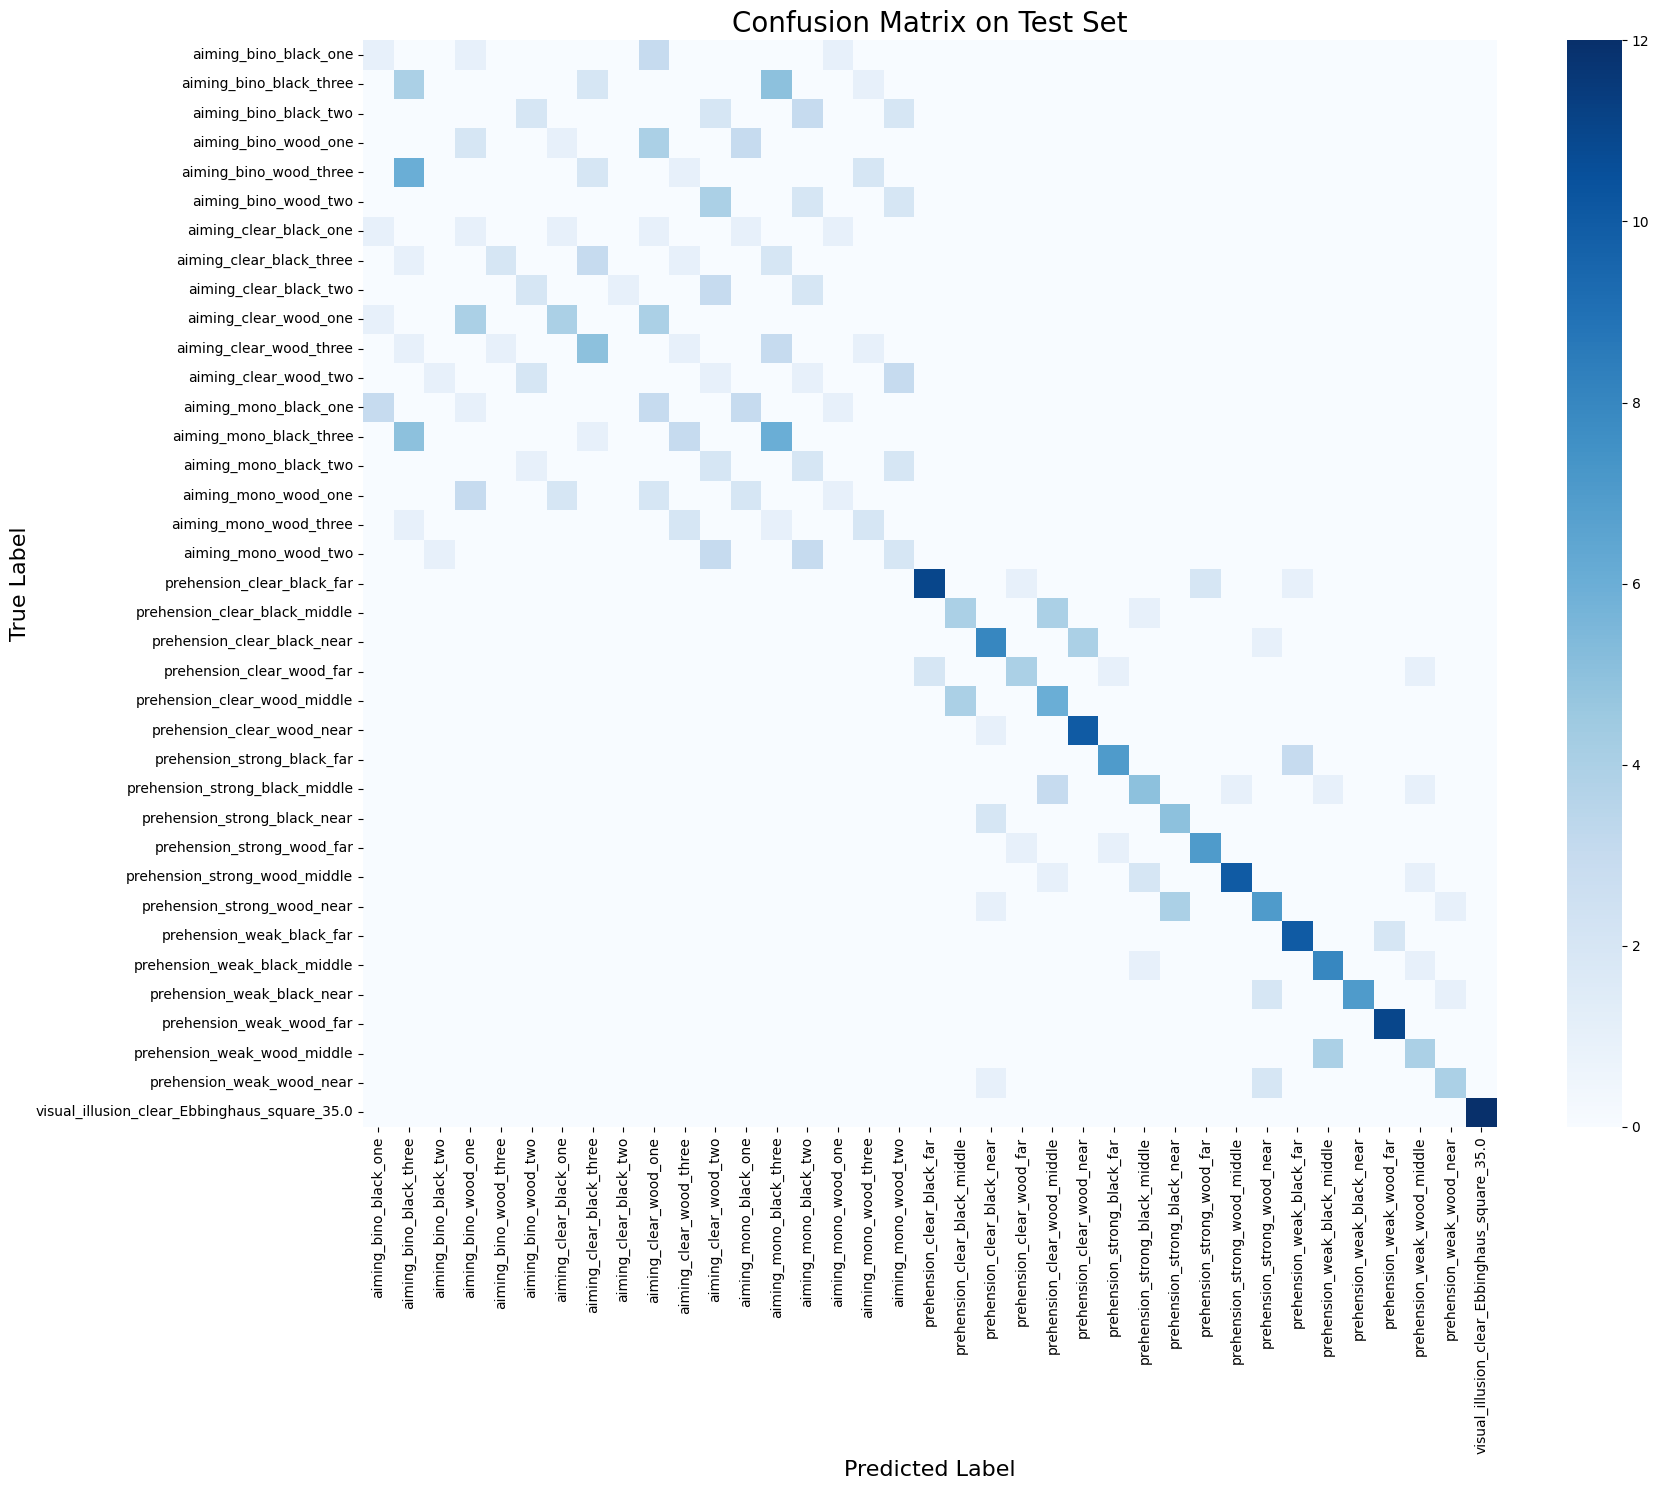

In [7]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix on Test Set", fontsize=20)
plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("True Label", fontsize=16)
plt.tight_layout()
plt.show()